In [1]:
%cd ../.
import sys

/home/gtamo/MS_ML


In [4]:
%load_ext autoreload
%autoreload 2

import re
import os
import pandas as pd
import numpy as np
import py3Dmol
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import plotly

from pathlib import Path
from rdkit import Chem
from rdkit.Chem import AllChem,rdFMCS
# import prolif as plf
from glob import glob
import meeko
import subprocess as sub
# from vina import Vina
import time
from tqdm import tqdm
tqdm.pandas()
import importlib
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from xgboost import XGBClassifier
from openTSNE import TSNE as oTSNE        # pip install openTSNE
import seaborn as sns

# user defined modules
import python.Rdkit_tools as rdkit_tools
importlib.reload(rdkit_tools)
import python.Molecule as M
import python.ML_Reg as ML_Reg
import python.ML_Class as ML_Class
from python.MolViz3D import MolViz3D
import python.Statistics_tools as stats_tools
import python.functions as fn

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# FUNCTIONS

# MAIN

| Source | Coverage | What you get | Free for industry? |
|---|---|---|---|
| ChEMBL | ~2.5 M compounds, bioactivities | SMILES, target (UniProt), assay, IC50/Ki/etc. | ✅ CC-BY |
| PubChem | 110 M+ compounds, 1.5 M assays | SMILES, target, activity outcome | ✅ |
| OpenTargets | ~63 k targets × ~25 k diseases | Target-disease evidence scores; links to ChEMBL drugs | ✅ |
| DrugCentral | ~5 k approved drugs | SMILES, indications, MoA, targets | ✅ CC-BY-SA |
| TTD (Therapeutic Target DB) | ~3.5 k targets, ~38 k drugs | Target ↔ drug ↔ disease | ✅ — manual download, no python client |
| DrugBank | ~14 k approved + experimental | Targets, indications, ADMET | Academic only — commercial needs license |

## 0. Imports

In [ ]:
## get ChEMBL — full molecule catalogue (~2.5M compounds with canonical SMILES)
## Downloads chembl_<version>_chemreps.txt.gz once (~150 MB) to data/external/chembl/
## locality: download only. Bump CHEMBL_VERSION to latest at
##   https://chembl.gitbook.io/chembl-interface-documentation/downloads
import os, urllib.request

CHEMBL_VERSION = 36
BULK_URL = (f'https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/releases/'
            f'chembl_{CHEMBL_VERSION}/chembl_{CHEMBL_VERSION}_chemreps.txt.gz')
LOCAL    = f'data/external/chembl/chembl_{CHEMBL_VERSION}_chemreps.txt.gz'
os.makedirs(os.path.dirname(LOCAL), exist_ok=True)
if not os.path.exists(LOCAL):
    print(f'  downloading {BULK_URL} → {LOCAL}  (one-time, ~150 MB)')
    urllib.request.urlretrieve(BULK_URL, LOCAL)

chembl_df = pd.read_csv(LOCAL, sep='\t', usecols=['chembl_id', 'canonical_smiles'])
chembl_df = (chembl_df.rename(columns={'chembl_id': 'compound', 'canonical_smiles': 'smiles'})
                       .dropna(subset=['smiles'])
                       .drop_duplicates('compound')
                       .reset_index(drop=True))
chembl_df['origin'] = 'ChEMBL'
print(f'ChEMBL v{CHEMBL_VERSION}: {len(chembl_df):,} compounds with SMILES')
chembl_df.head()

In [ ]:
%%time
chembl_df.to_csv('data/chemical_libs/chembl.csv',index=False,sep=',')

In [ ]:
## get OpenTargets — TARGET ↔ DISEASE association scores via GraphQL.
## Helper: fn.get_opentarget_disease_score(df, gene_col='gene', top_n=N)
## locality: REST queries to OpenTargets only — no project data sent.

# E3 ligases + targets relevant to Serac's PROTAC work
TARGETS = ['FBXO31', 'FBXO11', 'CRBN', 'VHL', 'MDM2', 'KEAP1',
           'DCAF1', 'DCAF15', 'BIRC2', 'BIRC3',          # IAP family
           'UBR1', 'UBR2', 'UBR4', 'UBR5']               # UBR family

ot_targets_df = fn.get_opentarget_disease_score(
    pd.DataFrame({'gene': TARGETS}),
    gene_col='gene', top_n=30,
)
print(f'\nOpenTargets: {len(ot_targets_df):,} (target, disease) rows '
      f'across {ot_targets_df["target_symbol"].nunique()} targets')
ot_targets_df.to_csv('data/chemical_libs/opentargets_target_disease.csv', index=False)
ot_targets_df.head()

In [ ]:
## get PubChem — random representative sample of ~N compounds via REST
## RESUMABLE: appends each batch to a checkpoint CSV. If this cell crashes or you
## interrupt the kernel, just re-run — it skips CIDs already fetched. Loss on
## crash is bounded to a single batch (≤100 compounds) between flushes.
## Robust to PubChem RemoteDisconnected / 5xx via Session + urllib3.Retry.
## locality: only the random CID list is sent in URLs; no project data leaves.
import os, random, time, requests, csv
from io import StringIO
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

random.seed(42)
TARGET_N    = 500_000                        # how many compounds you want
MAX_CID     = 175_000_000                    # rough upper bound; bump if needed
OVERSAMPLE  = 1.5                            # ~30% of CIDs are gaps → oversample
CHECKPOINT  = f'data/external/pubchem/pubchem_random_seed42_{TARGET_N}.csv'
os.makedirs(os.path.dirname(CHECKPOINT), exist_ok=True)

# 1. Pick the random CIDs (deterministic given the seed) — same set every run
cids = sorted(random.sample(range(1, MAX_CID + 1), int(TARGET_N * OVERSAMPLE)))

# 2. Resume: read existing checkpoint and remove already-done CIDs from the work list
done_cids = set()
if os.path.exists(CHECKPOINT) and os.path.getsize(CHECKPOINT) > 0:
    prev = pd.read_csv(CHECKPOINT)
    done_cids = set(prev['compound'].str.replace('CID', '', regex=False).astype(int))
    print(f'  resuming: {len(done_cids):,} CIDs already in {CHECKPOINT}')
todo = [c for c in cids if c not in done_cids]
print(f'  {len(todo):,} CIDs to fetch (of {len(cids):,} in the random sample)')

# 3. Make a robust HTTP session: keep-alive + auto-retry on connection drops + 5xx
session = requests.Session()
retry = Retry(
    total=5,                                 # retry up to 5 times per request
    backoff_factor=1.0,                      # 1, 2, 4, 8, 16 s between retries
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=['GET'],
    respect_retry_after_header=True,
)
session.mount('https://', HTTPAdapter(max_retries=retry, pool_connections=4, pool_maxsize=4))

# 4. Fetch in batches, flushing to CSV after each batch
BATCH = 100
write_header = (not os.path.exists(CHECKPOINT)) or os.path.getsize(CHECKPOINT) == 0
n_failed = 0
with open(CHECKPOINT, 'a', newline='') as fh:
    writer = csv.DictWriter(fh, fieldnames=['compound', 'smiles', 'origin'])
    if write_header:
        writer.writeheader()

    for i in tqdm(range(0, len(todo), BATCH), desc='PubChem random sample'):
        grp = todo[i:i + BATCH]
        url = ('https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/'
               f'{",".join(map(str, grp))}/property/SMILES/CSV')
        try:
            r = session.get(url, timeout=30)
            if r.ok and r.text.strip():
                df = pd.read_csv(StringIO(r.text))
                smi_cols = [c for c in df.columns if c != 'CID']
                if not smi_cols:
                    continue
                smi_col = smi_cols[0]
                for _, row in df.iterrows():
                    if pd.notna(row[smi_col]):
                        writer.writerow({'compound': f'CID{int(row.CID)}',
                                         'smiles':   row[smi_col],
                                         'origin':   'PubChem (random)'})
                fh.flush()                   # disk-safe past this point
        except Exception as e:
            n_failed += 1
            print(f'  batch {i} skipped — {type(e).__name__}: {e}  '
                  f'(re-run the cell to retry)')
            time.sleep(2.0)                  # back off after an error
        time.sleep(0.2)                      # 5 req/s — PubChem ToS rate limit

if n_failed:
    print(f'  {n_failed} batch(es) failed; re-run this cell to retry their CIDs.')

# 5. Load the final DataFrame from the checkpoint
pubchem_df = (pd.read_csv(CHECKPOINT)
              .drop_duplicates('compound')
              .head(TARGET_N)
              .reset_index(drop=True))
print(f'PubChem: {len(pubchem_df):,} compounds in {CHECKPOINT}')
pubchem_df.head()
pubchem_df.to_csv('data/chemical_libs/pubchem.csv',index=False,sep=',')

# ── ALTERNATIVES ──
# (1) Full SMILES table (every PubChem compound, ~7 GB compressed):
#       https://ftp.ncbi.nlm.nih.gov/pubchem/Compound/Extras/CID-SMILES.gz
#     Use this when you need *all* compounds; reservoir-sample locally for big random subsets.
# (2) Full SDF corpus (~100 GB, ~370 chunks of 500k compounds):
#       https://ftp.ncbi.nlm.nih.gov/pubchem/Compound/CURRENT-Full/SDF/
#     Use only if you need 3D conformers / properties / per-compound metadata beyond SMILES.

In [ ]:
## get DrugCentral — ~5k approved drugs with SMILES + indications + MoA
## locality: downloads a ~3 MB TSV from drugcentral.org. No project data sent.
## Note: DrugCentral hosts at unmtid-dbs.net under year-stamped paths and they
## update sporadically — bump if the URL 404s. Find the latest at
##   https://drugcentral.org/download  (look for "structures.smiles.tsv")
DRUGCENTRAL_URL = 'https://unmtid-dbs.net/download/DrugCentral/2021_09_01/structures.smiles.tsv'
df = pd.read_csv(DRUGCENTRAL_URL, sep='\t')
# Columns vary slightly across years — locate SMILES + ID columns robustly:
smiles_col = next((c for c in df.columns if 'SMILES' in c.upper()), None)
id_col     = next((c for c in df.columns if c.upper() in {'ID', 'DRUGCENTRAL_ID', 'STRUCT_ID'}), df.columns[0])
dc_df = (df[[id_col, smiles_col]]
         .rename(columns={id_col: 'compound', smiles_col: 'smiles'})
         .dropna(subset=['smiles'])
         .drop_duplicates('compound')
         .reset_index(drop=True))
dc_df['compound'] = 'DC' + dc_df['compound'].astype(str)
dc_df['origin']   = 'DrugCentral'
print(f'DrugCentral: {len(dc_df)} approved drugs with SMILES')
dc_df.head()
dc_df.to_csv('data/chemical_libs/drugcentral.csv',index=False,sep=',')

#### DrugBank and TTD — auth-gated, manual download

These two are listed in the table at the top but skipped here because they
don't have a clean public API:

- **DrugBank**: requires registration at [drugbank.com](https://drugbank.com)
  (academic license is free; commercial needs paid). Once you have
  `full database.xml.gz` saved under `data/drugbank/`, parse with `xml.etree.ElementTree`
  to extract drug ID + SMILES (one entry under `<calculated-property kind="SMILES">`).

- **TTD (Therapeutic Target DB)**: bulk files at
  [idrblab.net/ttd](https://idrblab.net/ttd/full-data-download). Format is
  unstable across versions; safest is to read `P1-04-Drug_information.txt`
  and join SMILES from `P2-01-TTD_uniprot_all.txt`. No python client exists.

In [ ]:
## get Protac-db
protac_df = pd.read_csv('data/chemical_libs/protac.csv')
protac_df

In [ ]:
## get crbn patented dataset — ~13k molecules from patent literature with CRBN binders
## Source: data/chemical_libs/patent_CRBN_mols_13k.sdf  (manual download)
## SDF has _Name = 'Compound N' (collides across patents) → prefix with 'CRBN-' so ids stay unique
crbn_patent_df = rdkit_tools.get_smiles_df_from_sdf(
    'data/chemical_libs/patent_CRBN_mols_13k.sdf',
    origin='PatentCRBN', compound_prefix='CRBN-',
)
print(f'PatentCRBN: {len(crbn_patent_df):,} molecules')
crbn_patent_df.to_csv('data/chemical_libs/patent_CRBN.csv', index=False)
crbn_patent_df.head()

In [ ]:
## get ttd dataset — Therapeutic Target Database drugs (~24k after sanitization)
## Source: data/chemical_libs/ttd.sdf  (manual download from idrblab.net/ttd)
## SDF _Name is the TTD drug ID (e.g. 'D00AAN') — already unique, no prefix needed
## ~3.7k records have malformed atom blocks ('HET' tokens) and are skipped silently.
ttd_df = rdkit_tools.get_smiles_df_from_sdf(
    'data/chemical_libs/ttd.sdf', origin='TTD',
)
print(f'TTD: {len(ttd_df):,} drugs')
ttd_df.to_csv('data/chemical_libs/ttd.csv', index=False)
ttd_df.head()

In [ ]:
## SERAC's library"
serac_df = (pd.read_csv('data/chemical_libs/20260430_SERAC_lib.csv')
            .drop(['CDD Number','Synonyms'],axis=1)
            .assign(origin='serac')
            .rename(columns={'Molecule Name':'compound','SMILES':'smiles','Projects':'project'}))
serac_df.head()

In [ ]:
## Other ligases — public E3-ligand database (PROTAC-DB / chembl-curated set).
## Source: data/chemical_libs/e3_ligand_database-latest.sdf  (~117 binders, 31 ligases)
## SDF tags used:
##   'Target' — E3 ligase / target name (MDM2, cIAP2, DCAF15, UBR2 box-2, …)
##   'Name'   — compound display name (e.g. 'Nutlin-3', 'MV1', 'ITE')
##   'Smiles' — kekulised SMILES (we re-canonicalise via RDKit for consistency
##              with the rest of the pipeline)
## Extra tags available but not pulled here: Kd/Ki/IC50/EC50, Uniprot, ChEMBL/PubChem ids,
## Covalent flag, MolWeight, cLogP. Add to the row dict if you need them later.
from rdkit import Chem, RDLogger
RDLogger.DisableLog('rdApp.*')

rows = []
for i, mol in enumerate(Chem.SDMolSupplier('data/chemical_libs/e3_ligand_database-latest.sdf')):
    if mol is None:
        continue
    name   = (mol.GetProp('Name')   if mol.HasProp('Name')   else '').strip() or f'compound_{i}'
    target = (mol.GetProp('Target') if mol.HasProp('Target') else '').strip() or 'unknown'
    rows.append({
        'compound': f'E3-{target}-{name}'.replace(' ', '_'),  # globally-unique id
        'name':     name,
        'target':   target,
        'smiles':   Chem.MolToSmiles(mol),
        'origin':   'E3-ligand-DB',
    })
RDLogger.EnableLog('rdApp.*')

e3_df = pd.DataFrame(rows)
print(f'> E3-ligand-DB: {len(e3_df)} compounds across {e3_df["target"].nunique()} unique ligases')
print('per-ligase counts (top 15):')
print(e3_df['target'].value_counts().head(15).to_string())

e3_df.to_csv('data/chemical_libs/e3_ligand_db.csv', index=False)
e3_df.head()

## 1. Cleaning and processing

In [88]:
chembl_df = pd.read_csv('data/chemical_libs/chembl.csv')
pubchem_df = pd.read_csv('data/chemical_libs/pubchem.csv')
dc_df = pd.read_csv('data/chemical_libs/drugcentral.csv')
crbn_patent_df = pd.read_csv('data/chemical_libs/patent_CRBN.csv')
serac_df = (pd.read_csv('data/chemical_libs/20260430_SERAC_lib.csv')
            .drop(['CDD Number','Synonyms'],axis=1)
            .assign(origin='serac')
            .rename(columns={'Molecule Name':'compound','SMILES':'smiles','Projects':'project'}))
e3_df = pd.read_csv('data/chemical_libs/e3_ligand_db.csv').rename(columns={'target':'label'})[['compound','label','smiles','origin']]

In [89]:
serac_df['label'] = serac_df['project'].replace('UBRs, FBXO31','UBRs')
serac_df_FBX = serac_df[serac_df['label']=='FBXO31']
serac_df_UBR = serac_df[serac_df['label']=='UBRs']

In [90]:
%%time
## subsampling:
sub_n              = 25000
chembl_df_sub      = stats_tools.downsample_df(chembl_df,sub_n)
pubchem_df_sub     = stats_tools.downsample_df(pubchem_df,sub_n)
crbn_patent_df_sub = stats_tools.downsample_df(crbn_patent_df,2000) # 1300
serac_df_FBX_sub   = stats_tools.downsample_df(serac_df_FBX,2000) # 1000
serac_df_UBR_sub   = stats_tools.downsample_df(serac_df_UBR,10000) # 1000

CPU times: user 1.26 s, sys: 166 ms, total: 1.43 s
Wall time: 1.56 s


In [91]:
## assign labels for plotting:
chembl_df_sub     = chembl_df_sub.assign(label='Research/Bioactivity')
pubchem_df_sub    = pubchem_df_sub.assign(label='Research/Bioactivity')
dc_df             = dc_df.assign(label='Marketed/Approved')
crbn_patent_df_sub= crbn_patent_df_sub.assign(label='CRBN')


## for serac we can assigns projects as labels: # chembl_df_sub,pubchem_df_sub,
combined_df = pd.concat([dc_df,crbn_patent_df_sub,serac_df_FBX_sub,serac_df_UBR_sub,e3_df]).reset_index(drop=True)

# del chembl_df, pubchem_df, dc_df, crbn_patent_df, serac_df

In [92]:
## thin wrapper locking in the chemical-space prep criteria so we apply the same
## filter to combined_df (and any later subset) without retyping the parameters.
##   - PROTAC-friendly MW window: 80–1600 Da
##   - up to 100 heavy atoms
##   - strip to the largest fragment (drops counter-ions, mixtures)
def filter_small_molecules(df):
    return rdkit_tools.filter_small_molecules(
        df,
        mw_max=1600, mw_min=80,
        heavy_atoms_max=100,
        keep_largest_fragment=True,
        verbose=True,
    )

combined_df_filtered = filter_small_molecules(combined_df)
print('\nper-origin breakdown after filtering:')
print(combined_df_filtered['origin'].value_counts().to_string())
combined_df_filtered.head()

small-mol filter:   0%|          | 0/9659 [00:00<?, ?it/s]

small-mol filter: 100%|██████████| 9659/9659 [00:01<00:00, 6074.59it/s]

kept 9,467 / 9,659 (98.0%)
  [  PASS] ok                      9,467
  [reject] too_few_atoms              54
  [reject] peptide_like               54
  [reject] smiles_too_long            48
  [reject] forbidden_atom             24
  [reject] too_light                   8
  [reject] too_many_atoms              3
  [reject] too_heavy                   1

per-origin breakdown after filtering:
origin
DrugCentral     3921
serac           3439
PatentCRBN      1990
E3-ligand-DB     117


,compound,smiles,origin,label,project
0,DC5392,CNC(=O)C1=C(C=C(C=C1)C2=NN3C(=CN=C3N=C2)CC4=CC...,DrugCentral,Marketed/Approved,NaN
1,DC5393,CC(C)(COC1=CN2C(=C(C=N2)C#N)C(=C1)C3=CN=C(C=C3...,DrugCentral,Marketed/Approved,NaN
2,DC5394,CCN1C2=CC(=NC=C2C=C(C1=O)C3=CC(=C(C=C3Br)F)NC(...,DrugCentral,Marketed/Approved,NaN
3,DC5395,C[C@]12CC[C@H]3[C@H]([C@@H]1C[C@H]([C@@H]2O)[1...,DrugCentral,Marketed/Approved,NaN
4,DC5396,C1=CC2=C(C=C1C3=CN=C(C=C3)[18F])NC4=C2C=NC=C4,DrugCentral,Marketed/Approved,NaN


In [93]:
combined_df_filtered.groupby('label').size().to_frame('count').sort_values('count',ascending=False).head(5)

,count
label,
Marketed/Approved,3921
CRBN,2008
FBXO31,1998
UBRs,1443
VHL,27


In [94]:
combined_df_filtered = combined_df_filtered.rename(columns={'compound':'old_name'}).reset_index(drop=True)

In [95]:
combined_df_filtered['compound'] = 'XX'+ combined_df_filtered.index.astype(str)
combined_df_filtered.to_csv('output/chemical_libs/combined_df_filtered_'+str(sub_n)+'.csv',sep=',',index=False)

In [96]:
## compute MFs:
combined_MF = rdkit_tools.get_MF_bits_from_df(combined_df_filtered,nBits=2048,v=True)

  0%|          | 0/9467 [00:00<?, ?it/s]

100%|██████████| 9467/9467 [00:03<00:00, 2423.31it/s]


#### 2. Plotting 2D

In [128]:
from numba import njit
@njit(fastmath=True, cache=True)
def tanimoto_dist_numba(a, b):
    dot = np.dot(a, b)
    return 1.0 - dot / (a.sum() + b.sum() - dot + 1e-12)

e_combined = oTSNE(metric=tanimoto_dist_numba,
                  neighbors='pynndescent',     # ← required for callables
                  n_jobs=8,
                  n_components=2,
                  perplexity=30,
                  early_exaggeration=3, # lower numbers forces clusters appart default is 12
                  verbose=True,
                  random_state=42).fit(combined_MF.drop('compound', axis=1).values.astype(np.float32))

--------------------------------------------------------------------------------
TSNE(early_exaggeration=3,
     metric=CPUDispatcher(<function tanimoto_dist_numba at 0x70cad55d8ae0>),
     n_jobs=8, neighbors='pynndescent', random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using NN descent approximate search using CPUDispatcher(<function tanimoto_dist_numba at 0x70cad55d8ae0>) distance...
   --> Time elapsed: 40.71 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.12 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.92 seconds
===> Running optimization with exaggeration=3.00, lr=3155.67 for 250 iterations...
Iteration   50, KL divergence 3.1387, 50 iterations in 1.2390 sec
Iteration  100, KL divergence 3.0082, 50 iterations in 1.2466 sec
Iteration  150, KL divergence 2.9200, 50 iterations in 1.2078 sec
Iteration  200, KL divergence 2.8714, 50 itera

In [129]:
%%time
## get embedding to df and save to parquet
e_df = pd.DataFrame(e_combined,columns=['e1','e2'])
e_df['compound'] = combined_MF['compound']
# e_df.to_parquet('output/chemical_libs/2026_tsne__'+str(sub_n)+'sub_1024MFs.parquet')

CPU times: user 2.63 ms, sys: 0 ns, total: 2.63 ms
Wall time: 2.56 ms


In [130]:
e_df_label = pd.merge(combined_df_filtered[['compound','label']],e_df)
print(e_df.shape)
e_df_label.head(3)

(9467, 3)


,compound,label,e1,e2
0,XX0,Marketed/Approved,-29.771947,-30.841379
1,XX1,Marketed/Approved,57.487687,-13.894167
2,XX2,Marketed/Approved,-19.029467,-19.455564


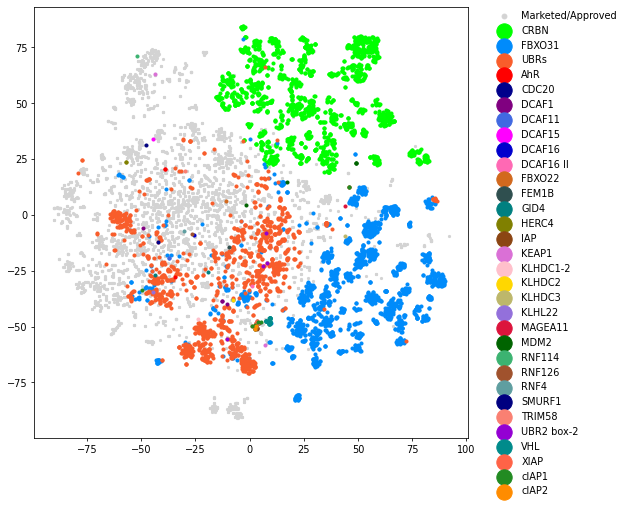

In [131]:
label2col = {
    # bulk backdrop
    'Research/Bioactivity': 'lightgrey',
    'Marketed/Approved':    'lightgrey',
    # SERAC priority targets
    'CRBN':                 'lime',
    'FBXO31':               '#008bfb',
    'UBRs':                 '#F95D2B',
    # E3-ligand-DB ligases (PROTAC-DB / chembl-curated)
    'AhR':                  'red',
    'CDC20':                'darkblue',
    'DCAF1':                'purple',
    'DCAF11':               'royalblue',
    'DCAF15':               'magenta',
    'DCAF16':               'mediumblue',
    'DCAF16 II':            'hotpink',
    'FBXO22':               'chocolate',
    'FEM1B':                'darkslategray',
    'GID4':                 'teal',
    'HERC4':                'olive',
    'IAP':                  'saddlebrown',
    'KEAP1':                'orchid',
    'KLHDC1-2':             'pink',
    'KLHDC2':               'gold',
    'KLHDC3':               'darkkhaki',
    'KLHL22':               'mediumpurple',
    'MAGEA11':              'crimson',
    'MDM2':                 'darkgreen',
    'RNF114':               'mediumseagreen',
    'RNF126':               'sienna',
    'RNF4':                 'cadetblue',
    'SMURF1':               'navy',
    'TRIM58':               'salmon',
    'UBR2 box-2':           'darkviolet',
    'VHL':                  'darkcyan',
    'XIAP':                 'tomato',
    'cIAP1':                'forestgreen',
    'cIAP2':                'darkorange',
}

# All non-bulk classes are rare → enlarge so they're visible against the backdrop.
_BULK = {'Research/Bioactivity', 'Marketed/Approved'}
label2marker_size = {lbl: (1 if lbl in _BULK else 10) for lbl in label2col}

# Plot bulk first (drawn underneath), then everything else on top.
class_order = (['Research/Bioactivity', 'Marketed/Approved']
               + [lbl for lbl in label2col if lbl not in _BULK])

# stats_tools.plot_multi_class_to_embedding(e_df_label,'label')

fig = stats_tools.plot_multi_class_to_embedding(
    e_df_label,                 # 2D version of the same e_df_label_3d
    label='label', e1='e1', e2='e2',
    colors=label2col,
    marker_size=label2marker_size,
    class_order=class_order,
    dpi=70
)


#### 2. Plotting 3D

In [116]:
from numba import njit
@njit(fastmath=True, cache=True)
def tanimoto_dist_numba(a, b):
    dot = np.dot(a, b)
    return 1.0 - dot / (a.sum() + b.sum() - dot + 1e-12)

e_combined_3d = oTSNE(metric=tanimoto_dist_numba,
                  neighbors='pynndescent',     # ← required for callables
                  n_jobs=8,
                  n_components=3,
                  perplexity=30,
                  early_exaggeration=12, # lower numbers forces clusters appart default is 12
                  negative_gradient_method='bh',
                  verbose=True,
                  random_state=42).fit(combined_MF.drop('compound', axis=1).values.astype(np.float32))

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12,
     metric=CPUDispatcher(<function tanimoto_dist_numba at 0x70cad655f880>),
     n_components=3, n_jobs=8, negative_gradient_method='bh',
     neighbors='pynndescent', random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using NN descent approximate search using CPUDispatcher(<function tanimoto_dist_numba at 0x70cad655f880>) distance...
   --> Time elapsed: 34.72 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.11 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.95 seconds
===> Running optimization with exaggeration=12.00, lr=788.92 for 250 iterations...
Iteration   50, KL divergence 4.8898, 50 iterations in 2.1618 sec
Iteration  100, KL divergence 4.9663, 50 iterations in 1.7005 sec
Iteration  150, KL divergence 4.9635, 50 iterations in 1.75

In [120]:
## plot 3d — interactive (drag to rotate, scroll to zoom, click legend to toggle classes)
## requires plotly:  pip install plotly  (in the `ml` conda env)

# 1) wrap the 3D embedding into a labelled dataframe + checkpoint to parquet
f_e3 = f'output/chemical_libs/20260505_tsne_3d_{sub_n}sub_{combined_MF.shape[0]-1}MFs_ligases_marketed.parquet'

if os.path.exists(f_e3):
    print(f"> loading {f_e3}")
    e_df_label_3d = pd.read_parquet(f_e3)
else:
    print("The file does not exist.")
    e_df_3d = pd.DataFrame(e_combined_3d, columns=['e1', 'e2', 'e3'])
    e_df_3d['compound'] = combined_MF['compound'].values
    e_df_label_3d = pd.merge(combined_df_filtered[['compound', 'label']], e_df_3d)
    e_df_label_3d.to_parquet(f_e3)


print(e_df_label_3d.shape)

> loading output/chemical_libs/20260505_tsne_3d_25000sub_9466MFs_ligases_marketed.parquet
(9467, 5)


In [121]:
e_df_label_3d.label.unique()

<ArrowStringArray>
['Marketed/Approved',              'CRBN',            'FBXO31',
              'UBRs',               'AhR',             'CDC20',
             'DCAF1',            'DCAF15',              'GID4',
             'HERC4',               'IAP',          'KLHDC1-2',
            'KLHDC2',            'KLHDC3',           'MAGEA11',
              'MDM2',            'SMURF1',            'TRIM58',
        'UBR2 box-2',               'VHL',              'XIAP',
             'cIAP1',             'cIAP2',            'KLHL22',
         'DCAF16 II',            'DCAF11',            'DCAF16',
            'FBXO22',             'FEM1B',             'KEAP1',
            'RNF114',            'RNF126',              'RNF4']
Length: 33, dtype: str

In [135]:
## drop labels that appear on only one compound (singletons clutter the annotation layer)
_lbl_counts  = e_df_label_3d['label'].value_counts()
_keep_labels = _lbl_counts[_lbl_counts > 1].index
e_df_label_3d_f = e_df_label_3d[e_df_label_3d['label'].isin(_keep_labels)].reset_index(drop=True)
print(f'> dropped {len(e_df_label_3d) - len(e_df_label_3d_f):,} singleton-label rows '
      f'({(_lbl_counts == 1).sum()} labels removed)')
print(f'> e_df_label_3d_f: {e_df_label_3d_f.shape}, '
      f'{e_df_label_3d_f["label"].nunique()} labels remaining')


> dropped 16 singleton-label rows (16 labels removed)
> e_df_label_3d_f: (9451, 5), 17 labels remaining


In [140]:
# 2) interactive 3D scatter coloured by `label`, compound id surfaced on hover
import plotly.io as pio

# 'vscode' renderer is built specifically for VSCode notebooks and uses the
# Jupyter MIME-bundle protocol (requires nbformat>=4.2 — already pinned).
# Inline render, no sandboxed iframe issues.
pio.renderers.default = 'vscode'

# setting style:
# Bulk classes stay neutral (grey/black). CRBN/FBXO31/UBRs keep their original
# colours. The 29 E3-ligand-DB ligases get distinct hues from a curated palette
# so they read as small bright islands on top of the ChEMBL/PubChem backdrop.
label2col = {
    # bulk backdrop
    'Research/Bioactivity': 'lightgrey',
    'Marketed/Approved':    'lightgrey',
    # SERAC priority targets
    'CRBN':                 'lime',
    'FBXO31':               '#008bfb',
    'UBRs':                 '#F95D2B',
    # E3-ligand-DB ligases (PROTAC-DB / chembl-curated)
    'AhR':                  'red',
    'CDC20':                'darkblue',
    'DCAF1':                'purple',
    'DCAF11':               'royalblue',
    'DCAF15':               'magenta',
    'DCAF16':               'mediumblue',
    'DCAF16 II':            'hotpink',
    'FBXO22':               'chocolate',
    'FEM1B':                'darkslategray',
    'GID4':                 'teal',
    'HERC4':                'olive',
    'IAP':                  'saddlebrown',
    'KEAP1':                'orchid',
    'KLHDC1-2':             'pink',
    'KLHDC2':               'gold',
    'KLHDC3':               'darkkhaki',
    'KLHL22':               'mediumpurple',
    'MAGEA11':              'crimson',
    'MDM2':                 'darkgreen',
    'RNF114':               'mediumseagreen',
    'RNF126':               'sienna',
    'RNF4':                 'cadetblue',
    'SMURF1':               'navy',
    'TRIM58':               'salmon',
    'UBR2 box-2':           'darkviolet',
    'VHL':                  'darkcyan',
    'XIAP':                 'tomato',
    'cIAP1':                'forestgreen',
    'cIAP2':                'darkorange',
}

# All non-bulk classes are rare → enlarge so they're visible against the backdrop.
_BULK = {'Research/Bioactivity', 'Marketed/Approved'}
label2marker_size = {lbl: (3 if lbl in _BULK else 5) for lbl in label2col}

# Plot bulk first (drawn underneath), then everything else on top.
class_order = (['Research/Bioactivity', 'Marketed/Approved']
               + [lbl for lbl in label2col if lbl not in _BULK])

fig = stats_tools.plot_multi_class_to_embedding_3d(
    e_df_label_3d_f, label='label',
    e1='e1', e2='e2', e3='e3',
    hover_cols=['label'],
    colors=label2col,
    marker_size=label2marker_size,
    class_order=class_order,
    opacity=.7, height=750, width=950,
)

# Annotate every remaining label (centroid-anchored) except the bulk backdrop
# and the three SERAC priority classes (already obvious from their colour).
# Override an entry in MANUAL_ANCHORS to anchor on a specific compound name
# substring instead of the class centroid.
EXCLUDE_FROM_ANNOT = {'Research/Bioactivity', 'Marketed/Approved',
                      'CRBN', 'FBXO31', 'UBRs'}
MANUAL_ANCHORS = {
    'VHL':   'VH032',
    'MDM2':  'nutlin',
    # add more if a specific compound is more representative than the centroid
}

LABEL_ANCHORS = {lbl: MANUAL_ANCHORS.get(lbl)              # None → centroid
                 for lbl in e_df_label_3d_f['label'].unique()
                 if lbl not in EXCLUDE_FROM_ANNOT}

def _medoid_xyz(sub):
    """Return the (e1, e2, e3) of the class member closest to the centroid.
    Avoids arrow heads landing in empty space when a class has multiple
    sub-clusters (e.g. MDM2 nutlin-like vs MI-class chemotypes)."""
    pts = sub[['e1', 'e2', 'e3']].values
    ctr = pts.mean(axis=0)
    return tuple(map(float, pts[((pts - ctr) ** 2).sum(axis=1).argmin()]))

annotations = []
for lbl, needle in LABEL_ANCHORS.items():
    sub = e_df_label_3d_f[e_df_label_3d_f['label'] == lbl]
    if sub.empty:
        continue
    if needle:
        hit = sub[sub['compound'].astype(str).str.contains(needle, case=False, na=False)]
        if not hit.empty:
            row = hit.iloc[0]
            x, y, z = float(row['e1']), float(row['e2']), float(row['e3'])
        else:
            print(f'  [annot] no compound matching {needle!r} in {lbl} — falling back to medoid')
            x, y, z = _medoid_xyz(sub)
    else:
        x, y, z = _medoid_xyz(sub)
    annotations.append(dict(
        x=x, y=y, z=z,
        text=f'<b>{lbl}</b>',
        showarrow=True, arrowhead=3, arrowsize=1.2, arrowwidth=1.5,
        arrowcolor=label2col.get(lbl, 'black'),
        ax=40, ay=-40,            # ax/ay are 2D pixel offsets in 3D plots
        font=dict(size=11, color='black'),
        bgcolor='rgba(255,255,255,0.75)', bordercolor='lightgrey', borderwidth=0.5,
    ))

fig.update_layout(scene=dict(annotations=annotations))

# write a sharable standalone HTML straight to the Windows Downloads folder
# (WSL mounts C: at /mnt/c/, so this file is double-clickable from Windows Explorer)
DOWNLOADS = '/mnt/c/Users/gtamo/Downloads'
os.makedirs(DOWNLOADS, exist_ok=True)
html_path = os.path.join(DOWNLOADS, os.path.basename(f_e3).replace('.parquet', '.html'))
fig.write_html(html_path, include_plotlyjs='cdn')
print(f'wrote {html_path}  ({os.path.getsize(html_path)/1e6:.1f} MB)')

fig.show()
# NOTE: this renderer embeds the figure JSON in the cell output, so the
# notebook will grow by ~2-3 MB after save. If you want to keep the file
# small, "Cell → Clear All Outputs" before saving (Ctrl-Shift-P → "Clear
# All Outputs"). The standalone html_path above is your durable copy.

  [annot] no compound matching 'nutlin' in MDM2 — falling back to medoid
  [annot] no compound matching 'VH032' in VHL — falling back to medoid
wrote /mnt/c/Users/gtamo/Downloads/20260505_tsne_3d_25000sub_9466MFs_ligases_marketed.html  (0.5 MB)
